# Book Average Rating Prediction

Dataset: Goodreads books metadata (11,123 books, 12 columns).
Task: regression, predict `average_rating` from book metadata.
Pipeline: data cleaning, EDA, leakage-safe feature engineering, model training, evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv("data/books.csv", on_bad_lines="skip")
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

(11123, 12)


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  str    
 2   authors             11123 non-null  str    
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  str    
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  str    
 7   num_pages           11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  str    
 11  publisher           11123 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


## 2. Data Cleaning

In [4]:
# drop unrated books
df = df[df["average_rating"] > 0].reset_index(drop=True)

# drop duplicate ISBNs
df = df.drop_duplicates(subset="isbn").reset_index(drop=True)

# parse publication_date, drop unparseable rows
df["publication_date"] = pd.to_datetime(df["publication_date"], format="mixed", errors="coerce")
df = df.dropna(subset=["publication_date"]).reset_index(drop=True)

print(df.shape)
df.isnull().sum()

(11096, 12)


bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [5]:
# remove physically implausible page counts
df = df[(df["num_pages"] > 0) & (df["num_pages"] < 3000)].reset_index(drop=True)
print(df.shape)

(11015, 12)


## 3. Exploratory Data Analysis

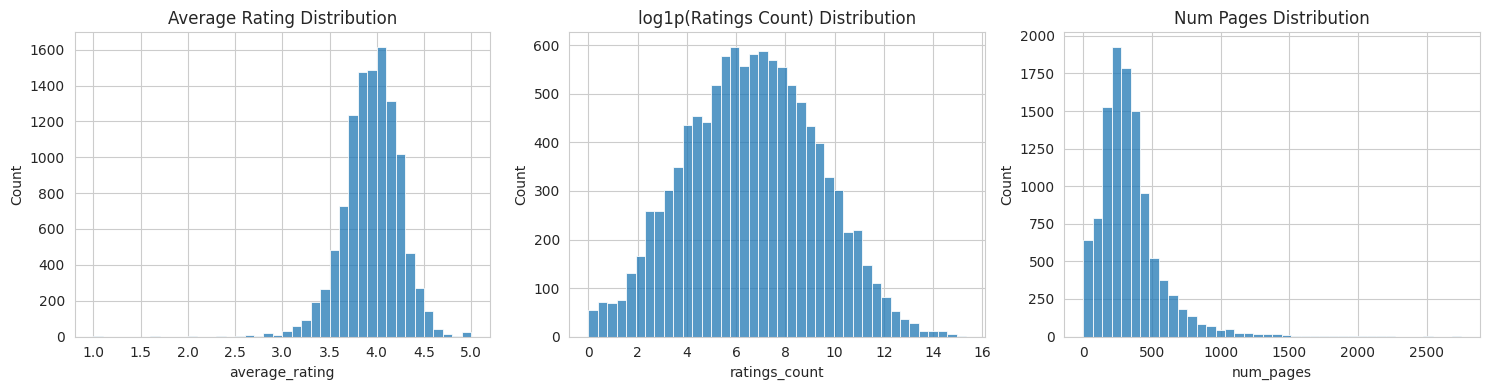

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["average_rating"], bins=40, ax=axes[0])
axes[0].set_title("Average Rating Distribution")
sns.histplot(np.log1p(df["ratings_count"]), bins=40, ax=axes[1])
axes[1].set_title("log1p(Ratings Count) Distribution")
sns.histplot(df["num_pages"], bins=40, ax=axes[2])
axes[2].set_title("Num Pages Distribution")
plt.tight_layout()
plt.show()

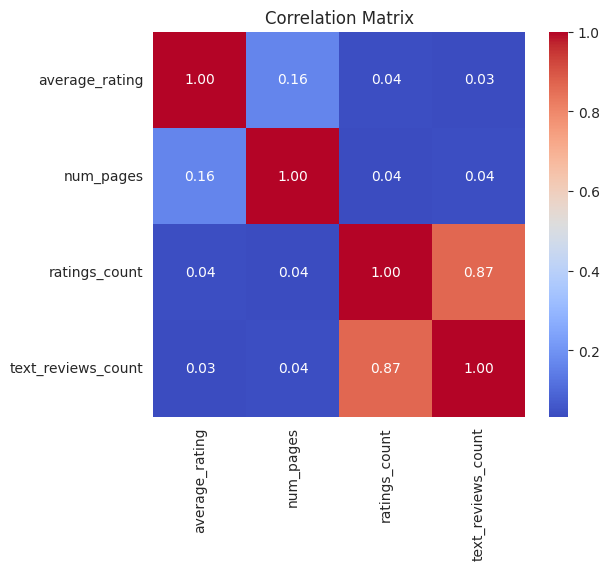

In [7]:
corr_cols = ["average_rating", "num_pages", "ratings_count", "text_reviews_count"]
corr = df[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

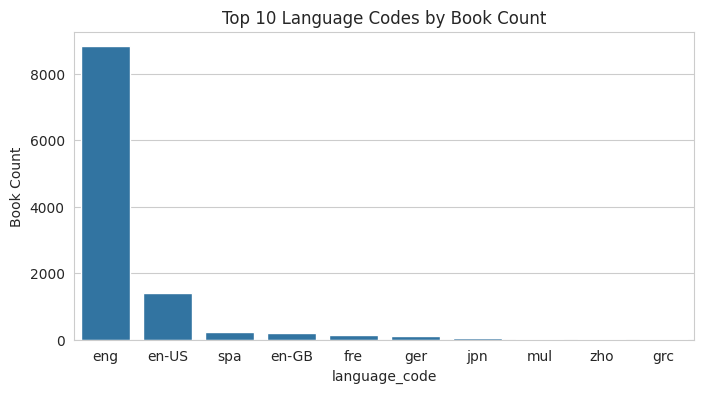

In [8]:
top_languages = df["language_code"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_languages.index, y=top_languages.values)
plt.title("Top 10 Language Codes by Book Count")
plt.ylabel("Book Count")
plt.show()

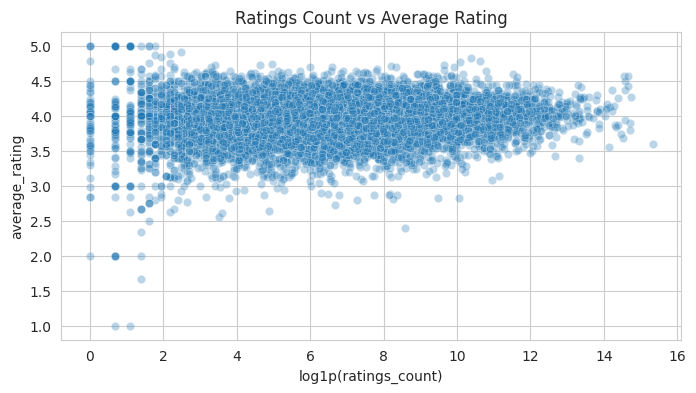

In [9]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x=np.log1p(df["ratings_count"]), y=df["average_rating"], alpha=0.3)
plt.xlabel("log1p(ratings_count)")
plt.ylabel("average_rating")
plt.title("Ratings Count vs Average Rating")
plt.show()

## 4. Feature Engineering (row-level)

Only deterministic, row-level transforms happen before the split.
Group-level statistics (author frequency, publisher frequency, language bucketing) are computed
after the split, inside the modeling pipeline, so they never see test rows during fitting.

In [10]:
data = df.copy()

# temporal features
data["pub_year"] = data["publication_date"].dt.year
data["pub_month"] = data["publication_date"].dt.month
data["book_age"] = data["publication_date"].dt.year.max() + 1 - data["pub_year"]

# log-transform skewed count features
data["log_ratings_count"] = np.log1p(data["ratings_count"])
data["log_text_reviews_count"] = np.log1p(data["text_reviews_count"])

# review engagement ratio
data["review_ratio"] = data["text_reviews_count"] / (data["ratings_count"] + 1)

# co-author count
data["num_authors"] = data["authors"].str.split("/").apply(len)

data.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,pub_year,pub_month,book_age,log_ratings_count,log_text_reviews_count,review_ratio,num_authors
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,2006-09-16,Scholastic Inc.,2006,9,15,14.555394,10.225281,0.013166,2
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,2004-09-01,Scholastic Inc.,2004,9,17,14.582451,10.282677,0.013571,2
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,2003-11-01,Scholastic,2003,11,18,8.753687,5.501258,0.038522,1
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,2004-05-01,Scholastic Inc.,2004,5,17,14.665485,10.500289,0.015526,2
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic,2004,9,17,10.631736,5.105945,0.003959,2


## 5. Train-Test Split

The split happens before any author, publisher, or language-frequency statistics are computed.
Those statistics are learned only from the training rows in the next section.

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)
y_train = train_df["average_rating"].copy()
y_test = test_df["average_rating"].copy()

print(train_df.shape, test_df.shape)

(8812, 19) (2203, 19)


## 6. Leakage-Safe Preprocessing

`author_book_count`, `publisher_book_count`, and their frequency ratios in the original notebook
were computed once over the full dataset before the split. That leaks test-set author and
publisher composition into training features, and leaks it again into every cross-validation fold
during hyperparameter search.

Two custom transformers replace that step. `GroupFrequencyEncoder` learns category counts only from
the data it is fit on and maps unseen categories to zero. `TopCategoryGrouper` learns the top-N
language codes only from the fit data. Both are placed inside a `ColumnTransformer`, which itself sits
inside each model's `Pipeline`, so `GridSearchCV` refits them fold-by-fold with no access to held-out rows.

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class GroupFrequencyEncoder(BaseEstimator, TransformerMixin):
    """Encodes a categorical column as raw count and relative frequency,
    learned only from the fit split. Unseen categories map to zero."""

    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        self.counts_ = X[self.column].value_counts()
        self.n_ = len(X)
        return self

    def transform(self, X):
        count_col = f"{self.column}_book_count"
        freq_col = f"{self.column}_freq"
        out = pd.DataFrame(index=X.index)
        out[count_col] = X[self.column].map(self.counts_).fillna(0)
        out[freq_col] = out[count_col] / self.n_
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{self.column}_book_count", f"{self.column}_freq"])


class TopCategoryGrouper(BaseEstimator, TransformerMixin):
    """Buckets a categorical column into its top-N categories from the
    fit split, everything else becomes 'other'."""

    def __init__(self, column, top_n=5):
        self.column = column
        self.top_n = top_n

    def fit(self, X, y=None):
        self.top_categories_ = X[self.column].value_counts().head(self.top_n).index.tolist()
        return self

    def transform(self, X):
        out = pd.DataFrame(index=X.index)
        out[self.column] = X[self.column].where(X[self.column].isin(self.top_categories_), "other")
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([self.column])


numeric_passthrough = [
    "num_pages", "log_ratings_count", "log_text_reviews_count",
    "review_ratio", "pub_year", "pub_month", "book_age", "num_authors",
]

preprocessor = ColumnTransformer(transformers=[
    ("numeric", "passthrough", numeric_passthrough),
    ("author_freq", GroupFrequencyEncoder("authors"), ["authors"]),
    ("publisher_freq", GroupFrequencyEncoder("publisher"), ["publisher"]),
    ("language_ohe", Pipeline([
        ("group", TopCategoryGrouper("language_code", top_n=5)),
        ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), ["language_code"]),
])

## 7. Model Training

Dataset size (~11k rows, ~17 encoded features) favors classical ML over deep learning.
Ridge, Random Forest, XGBoost, and a stacking ensemble are trained, each wrapped in a pipeline
with the shared preprocessing step so no model sees a leaked feature at any stage.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


def evaluate(model, X_te, y_te, name):
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    print(f"{name}: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}


results = []

In [14]:
ridge_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("scale", StandardScaler()),
    ("model", Ridge(random_state=RANDOM_STATE)),
])
ridge_grid = GridSearchCV(ridge_pipe, {"model__alpha": [0.1, 1.0, 10.0]}, cv=3, scoring="r2", n_jobs=1)
ridge_grid.fit(train_df, y_train)
ridge_best = ridge_grid.best_estimator_
print("Best Ridge params:", ridge_grid.best_params_)
results.append(evaluate(ridge_best, test_df, y_test, "Ridge"))

Best Ridge params: {'model__alpha': 1.0}
Ridge: RMSE=0.2885 MAE=0.2160 R2=0.0727


In [15]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])
rf_params = {"model__n_estimators": [100, 200], "model__max_depth": [8, 12]}
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=3, scoring="r2", n_jobs=1)
rf_grid.fit(train_df, y_train)
rf_best = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)
results.append(evaluate(rf_best, test_df, y_test, "Random Forest"))

Best RF params: {'model__max_depth': 12, 'model__n_estimators': 100}
Random Forest: RMSE=0.2754 MAE=0.2026 R2=0.1546


In [16]:
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0)),
])
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}
xgb_grid = GridSearchCV(xgb_pipe, xgb_params, cv=3, scoring="r2", n_jobs=1)
xgb_grid.fit(train_df, y_train)
xgb_best = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)
results.append(evaluate(xgb_best, test_df, y_test, "XGBoost"))

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
XGBoost: RMSE=0.2750 MAE=0.2047 R2=0.1571


In [17]:
stack = StackingRegressor(
    estimators=[
        ("ridge", ridge_best),
        ("rf", rf_best),
        ("xgb", xgb_best),
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=1,
    cv=3,
)
stack.fit(train_df, y_train)
results.append(evaluate(stack, test_df, y_test, "Stacking Ensemble"))

Stacking Ensemble: RMSE=0.2743 MAE=0.2037 R2=0.1614


## 8. Model Comparison

In [18]:
results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
results_df

,model,rmse,mae,r2
0,Stacking Ensemble,0.274336,0.203726,0.161351
1,XGBoost,0.275027,0.204739,0.157123
2,Random Forest,0.275445,0.202647,0.154557
3,Ridge,0.288466,0.216043,0.072731


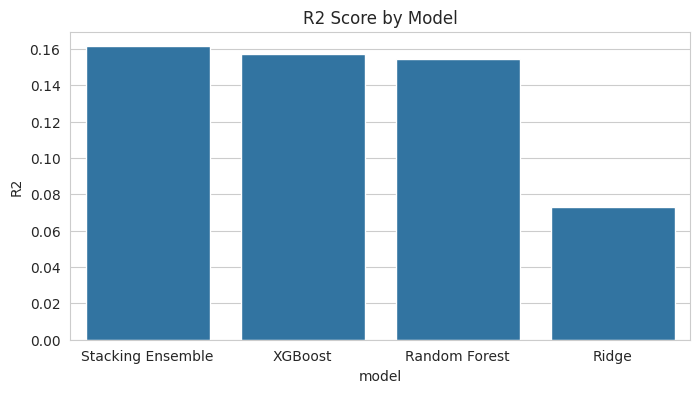

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="r2")
plt.title("R2 Score by Model")
plt.ylabel("R2")
plt.show()

## 9. Feature Importance (XGBoost)

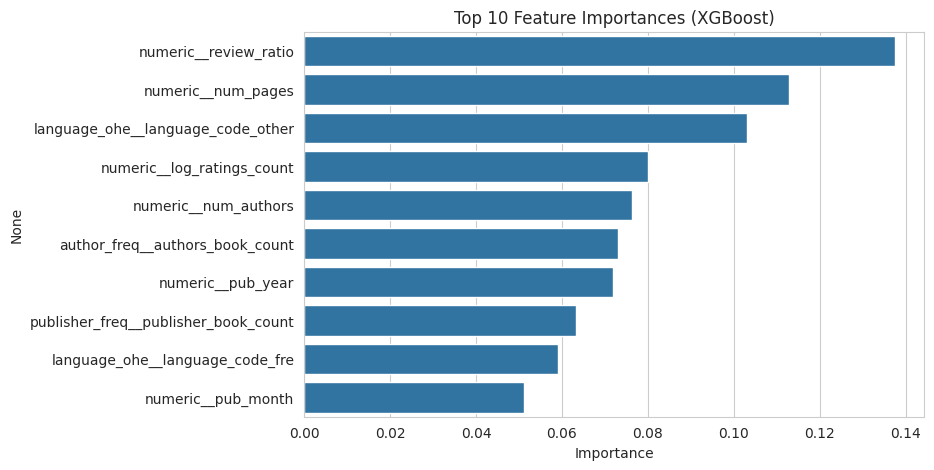

In [20]:
feature_names = xgb_best.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(
    xgb_best.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

## 10. Final Evaluation on Best Model

In [21]:
best_row = results_df.iloc[0]
print(f"Best model: {best_row['model']}")
print(f"RMSE: {best_row['rmse']:.4f}")
print(f"MAE: {best_row['mae']:.4f}")
print(f"R2: {best_row['r2']:.4f}")

Best model: Stacking Ensemble
RMSE: 0.2743
MAE: 0.2037
R2: 0.1614


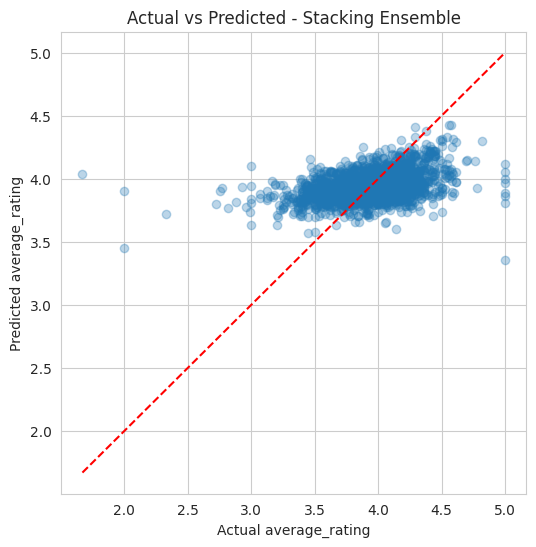

In [22]:
model_map = {
    "Ridge": ridge_best,
    "Random Forest": rf_best,
    "XGBoost": xgb_best,
    "Stacking Ensemble": stack,
}
best_model = model_map[best_row["model"]]
preds = best_model.predict(test_df)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual average_rating")
plt.ylabel("Predicted average_rating")
plt.title(f"Actual vs Predicted - {best_row['model']}")
plt.show()